In [151]:
import numpy as np 
import pandas as pd

In [152]:
transactions = pd.read_csv("dataset/project_transactions.csv")
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.0,0.0
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.0,0.0
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.0,0.0
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.0,0.0
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.0,0.0


## Data Exploration

### Data Reduction

In [153]:
# Transactions max "DAY" column value is 711 so DAY column can be reduced from int64 to int16
# Transactions max "QUANTITY" column value is 89638 so QUANTITY column can be reduced from int64 to int32
# Transactions max "STORE_ID" column value is 34280 so STORE_ID column can be reduced from int64 to int32
# Transactions max "WEEK_NO" column value is 102 so WEEK_NO column can be reduced from int64 to int8
print(transactions.loc[:, "DAY"].max())
print(transactions.loc[:, "QUANTITY"].max())
print(transactions.loc[:, "STORE_ID"].max())
print(transactions.loc[:, "WEEK_NO"].max())

711
89638
34280
102


In [154]:
transactions.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int64  
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(7)
memory usage: 180.1 MB


In [155]:
transactions = transactions.astype({
                        "DAY":"int16",
                        "QUANTITY":"int32",
                        "STORE_ID":"int32",
                        "WEEK_NO":"int8"
                    })

In [156]:
# drop from 180.1mb to 137.1mb
transactions.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int16  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int32  
 5   SALES_VALUE        float64
 6   STORE_ID           int32  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int8   
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int16(1), int32(2), int64(3), int8(1)
memory usage: 137.1 MB


### Missing data

In [157]:
# No missing data
transactions.isna().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

### Unique households and products

In [158]:
# 2099 unique households
# 84138 unique products
transactions.loc[:, ["household_key", "PRODUCT_ID"]].nunique()

household_key     2099
PRODUCT_ID       84138
dtype: int64

## Column Creation

In [159]:
transactions["total_discount"] = transactions["RETAIL_DISC"] + transactions["COUPON_DISC"]

conditions = [
    ((transactions["total_discount"] / transactions["SALES_VALUE"]).abs() > 1),
    ((transactions["total_discount"] / transactions["SALES_VALUE"]).abs() < 0)
]
choices = [1, 0]

transactions["discount_pct"] = np.select(conditions, choices, (transactions["total_discount"] / transactions["SALES_VALUE"]).abs())

In [ ]:
transactions = transactions.drop(columns=["RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"])
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,total_discount,discount_pct
0,1364,26984896261,1,842930,1,2.19,31742,1,0.00,0.000000
1,1364,26984896261,1,897044,1,2.99,31742,1,-0.40,0.133779
2,1364,26984896261,1,920955,1,3.09,31742,1,0.00,0.000000
3,1364,26984896261,1,937406,1,2.50,31742,1,-0.99,0.396000
4,1364,26984896261,1,981760,1,0.60,31742,1,-0.79,1.000000


## Overall Statistics

In [227]:
total_sales=transactions.loc[:, "SALES_VALUE"].sum()
total_discount=transactions.loc[:, "total_discount"].sum()
total_quantity = transactions.loc[:, "QUANTITY"].sum()

print("total_sales:", total_sales)
print("total_discount:", total_discount)
print("overall percentage discount:", (total_discount / total_sales))
print("total_quantity:", total_quantity)

total_sales: 6666243.5
total_discount: -1178658.08
overall percentage discount: -0.1768099350106248
total_quantity: 216713611


In [162]:
print(transactions.loc[:, "QUANTITY"].max())
transactions.loc[transactions.loc[:, "QUANTITY"] == transactions.loc[:, "QUANTITY"].max()]

89638


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,total_discount,discount_pct
1442095,630,34749153595,503,6534178,89638,250.0,384,73,-13.45,0.0538


In [176]:
print("Total sales value per basket:", total_sales / transactions.loc[:, "BASKET_ID"].nunique())
print("Total sales value per household:",total_sales / transactions.loc[:, "household_key"].nunique())

Total sales value per basket: 28.617979385160922
Total sales value per household: 3175.914006669843


## Household Analysis

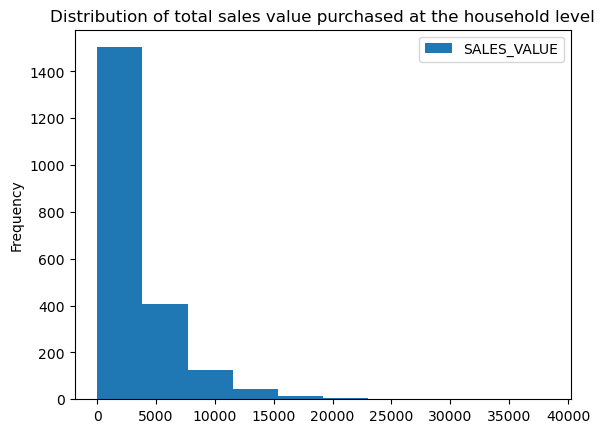

In [195]:
(transactions
    .groupby("household_key")
    .agg({"SALES_VALUE": "sum"})
).plot.hist(title="Distribution of total sales value purchased at the household level");

In [204]:
# top 10 households by quantity purchased
(transactions
    .groupby("household_key")
    .agg({"QUANTITY":"sum"})
    .sort_values(by="QUANTITY", ascending=False)
).iloc[:10]

,QUANTITY
household_key,
1023,4479917
755,3141769
1609,2146715
13,1863829
1430,1741892
1527,1734632
1762,1669880
707,1640193
1029,1496204


In [263]:
# top 10 households by sales value
top10_households_by_sv = (transactions
    .groupby("household_key")
    .agg({"SALES_VALUE":"sum"})
    .sort_values(by="SALES_VALUE", ascending=False)
).iloc[:10]
top10_households_by_sv

,SALES_VALUE
household_key,
1023,38319.79
1609,27859.68
1453,21661.29
1430,20352.99
718,19299.86
707,19194.42
1653,19153.75
1111,18894.72
982,18790.34


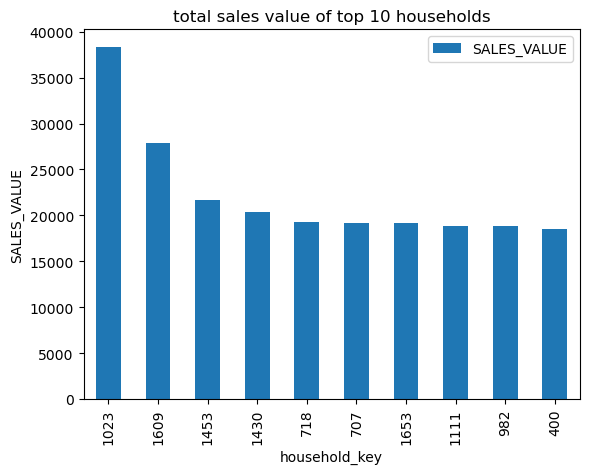

In [213]:
(transactions
    .groupby("household_key")
    .agg({"SALES_VALUE":"sum"})
    .sort_values(by="SALES_VALUE", ascending=False)
).iloc[:10].reset_index().plot.bar(x="household_key",
                                   y="SALES_VALUE",
                                   ylabel="SALES_VALUE",
                                   title="total sales value of top 10 households");

## Product Analysis

In [214]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,total_discount,discount_pct
0,1364,26984896261,1,842930,1,2.19,31742,1,0.00,0.000000
1,1364,26984896261,1,897044,1,2.99,31742,1,-0.40,0.133779
2,1364,26984896261,1,920955,1,3.09,31742,1,0.00,0.000000
3,1364,26984896261,1,937406,1,2.50,31742,1,-0.99,0.396000
4,1364,26984896261,1,981760,1,0.60,31742,1,-0.79,1.000000


In [246]:
top10_products = (transactions
                    .groupby(["PRODUCT_ID"])
                    .agg({"SALES_VALUE":"sum"})
                    .sort_values(by="SALES_VALUE", ascending=False)
                    .iloc[:10]
                 )
top10_products

,SALES_VALUE
PRODUCT_ID,
6534178,420154.13
6533889,42339.31
1029743,33894.75
1082185,24149.79
6533765,23831.14
6534166,23755.70
1106523,22931.01
916122,22749.02
995242,21229.72


<Axes: ylabel='PRODUCT_ID'>

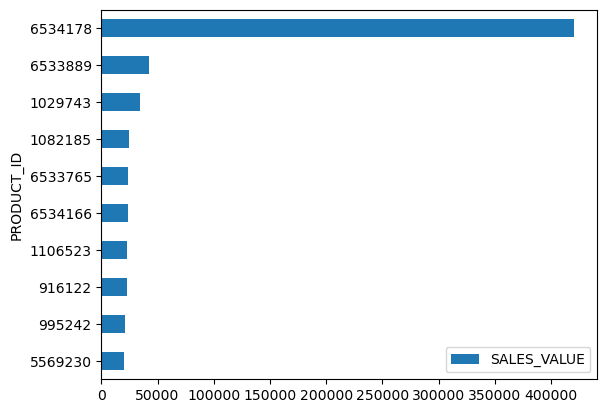

In [252]:
top10_products.sort_values(by="SALES_VALUE", ascending=True).plot.barh()

In [254]:
print((transactions
    .query("PRODUCT_ID in @top10_products.index")
    .loc[:, "total_discount"]
    .sum()
) / (transactions
    .query("PRODUCT_ID in @top10_products.index")
    .loc[:, "SALES_VALUE"]
    .sum()
))

-0.10331267387397926


In [284]:
(transactions
    .query("household_key in @top10_households_by_sv.index")
    .loc[:, "PRODUCT_ID"]
    .value_counts()
    .iloc[:10]
    .index
)

Index([1082185, 1029743, 6534178, 6533889, 1127831,  951590,  860776, 1106523,
        981760, 9677202],
      dtype='int64', name='PRODUCT_ID')

In [257]:
product = pd.read_csv("dataset/product.csv")
product.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [285]:
product.query("PRODUCT_ID in @top10_products.index")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
16863,916122,4314,MEAT,National,CHICKEN,CHICKEN BREAST BONELESS,
25754,995242,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,
29657,1029743,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
35576,1082185,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
38262,1106523,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
53097,5569230,1208,GROCERY,National,SOFT DRINKS,SOFT DRINKS 12/18&15PK CAN CAR,12 OZ
57171,6533765,69,KIOSK-GAS,Private,FUEL,GASOLINE-REG UNLEADED,
57181,6533889,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57216,6534166,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


In [ ]:
# product that have the highest quantity sold in a single row
highest_quantity_sold_IASR_product = (transactions
    .loc[transactions.loc[:,"QUANTITY"] == transactions.loc[:, "QUANTITY"].max()]
    .loc[:, "PRODUCT_ID"]
    .values
)
highest_quantity_sold_IASR_product

array([6534178])

In [296]:
product.query("PRODUCT_ID == @highest_quantity_sold_IASR_product")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
